In [1]:
import torch

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

In [2]:
import os

os.environ["HF_HOME"] = "models"

In [3]:
from transformers import GPT2Model, GPT2Tokenizer

model_name = "gpt2"
tokenizer = GPT2Tokenizer.from_pretrained(model_name)
model = GPT2Model.from_pretrained(
    model_name,
    output_hidden_states=True
)

model = model.to(device)
model.eval()
tokenizer.pad_token = tokenizer.eos_token

/Users/armaanjagirdar/Projects/SAE_GPT2/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 10685.76it/s]


In [4]:
from datasets import load_dataset

dataset = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1", split="train")
texts = [
    x["text"]
    for x in dataset
    if len(x["text"].strip()) > 50
]
texts = texts[:5000]

In [5]:
LAYER = 6
MAX_LENGTH = 128
BATCH_SIZE = 16

In [6]:
from tqdm.auto import tqdm

activations = []
metadata = []

with torch.no_grad():
    for i in tqdm(range(0, len(texts), BATCH_SIZE)):
        batch_texts = texts[i:i + BATCH_SIZE]

        tokens = tokenizer(
            batch_texts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH
        )

        input_ids = tokens["input_ids"].to(device)
        attention_mask = tokens["attention_mask"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        hidden = outputs.hidden_states[LAYER]
        mask = attention_mask.bool()

        batch_activations = hidden[mask]

        activations.append(batch_activations.detach().cpu())
        for b, text in enumerate(batch_texts):
            valid_positions = attention_mask[b].nonzero(as_tuple=True)[0]
            for pos in valid_positions:
                metadata.append({
                    "text": text,
                    "token": tokenizer.decode(input_ids[b, pos]),
                    "position": pos.item(),
                })

activations = torch.cat(activations)

100%|██████████| 313/313 [05:11<00:00,  1.00it/s]


In [7]:
mean = activations.mean(dim=0, keepdim=True)
std = activations.std(dim=0, keepdim=True) + 1e-6

activations = (activations - mean) / std
print(activations.mean().item(), activations.std().item())

-4.024822697346053e-09 0.9999985098838806


In [8]:
import torch.nn as nn
import torch.nn.functional as F

class TopKSparseAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim, k=32):
        super().__init__()
        self.k = k
        self.encoder = nn.Linear(input_dim, latent_dim)
        self.decoder = nn.Linear(latent_dim, input_dim)

    def encode(self, x):
        pre_acts = F.relu(self.encoder(x))
        topk_vals, topk_indices = torch.topk(pre_acts, self.k, dim=-1)
        z = torch.zeros_like(pre_acts)
        z.scatter_(-1, topk_indices, topk_vals)
        return z

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        z = self.encode(x)
        x_hat = self.decode(z)
        return x_hat, z

In [9]:
INPUT_DIM = activations.shape[1]
LATENT_DIM = 2048
K = 32

torch.manual_seed(42)
sae = TopKSparseAutoencoder(input_dim=INPUT_DIM, latent_dim=LATENT_DIM, k=K).to(device)

print(sae)
print(f"Target L0 sparsity: {K} / {LATENT_DIM} ({K / LATENT_DIM:.2%})")

TopKSparseAutoencoder(
  (encoder): Linear(in_features=768, out_features=2048, bias=True)
  (decoder): Linear(in_features=2048, out_features=768, bias=True)
)
Target L0 sparsity: 32 / 2048 (1.56%)


In [10]:
optimizer = torch.optim.Adam(sae.parameters(),lr=1e-3)

In [11]:
BATCH_SIZE = 512
EPOCHS = 5

for epoch in range(EPOCHS):
    permutation = torch.randperm(len(activations))
    total_loss = 0
    total_recon = 0

    for i in tqdm(range(0, len(activations), BATCH_SIZE), desc=f"Epoch {epoch + 1}/{EPOCHS}"):
        indices = permutation[i:i + BATCH_SIZE]
        
        x = activations[indices].to(device)
        x_hat, z = sae(x)
        reconstruction_loss = F.mse_loss(x_hat, x)

        loss = reconstruction_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            sae.decoder.weight.data = F.normalize(sae.decoder.weight.data, dim=0)

        total_loss += loss.item()
        total_recon += reconstruction_loss.item()

    n_batches = (len(activations) + BATCH_SIZE - 1) // BATCH_SIZE

    print(
        f"loss={total_loss/n_batches:.5f} | "
        f"recon={total_recon/n_batches:.5f} | "
        f"fixed_k={sae.k}"
    )

Epoch 1/5: 100%|██████████| 991/991 [00:18<00:00, 53.65it/s]


loss=0.34880 | recon=0.34880 | fixed_k=32


Epoch 2/5: 100%|██████████| 991/991 [00:13<00:00, 71.64it/s] 


loss=0.24893 | recon=0.24893 | fixed_k=32


Epoch 3/5: 100%|██████████| 991/991 [00:15<00:00, 62.23it/s]


loss=0.23675 | recon=0.23675 | fixed_k=32


Epoch 4/5: 100%|██████████| 991/991 [00:16<00:00, 61.09it/s]


loss=0.23162 | recon=0.23162 | fixed_k=32


Epoch 5/5: 100%|██████████| 991/991 [00:15<00:00, 62.84it/s]

loss=0.22873 | recon=0.22873 | fixed_k=32


In [12]:
with torch.no_grad():
    sample = activations[:5000].to(device)
    _, z = sae(sample)
    active_fraction = (z > 0).float().mean()
    active_per_token = (z > 0).float().sum(dim=-1).mean()

print(f"Fraction of active features: {active_fraction.item():.4%}")
print(f"Average active features per token (L0): {active_per_token.item():.2f} (exact k={sae.k})")

Fraction of active features: 1.5625%
Average active features per token (L0): 32.00 (exact k=32)


In [13]:
FEATURE_ID = 100

feature_activations = []

with torch.no_grad():
    z = []
    for i in range(0, len(activations), BATCH_SIZE):
        batch = activations[i:i+BATCH_SIZE].to(device)
        z_batch = sae.encode(batch)
        z.append(z_batch[:, FEATURE_ID].cpu())

feature_activations = torch.cat(z)
print(feature_activations.max().item())

15.978934288024902


In [14]:
top_k = 10

values, indices = torch.topk(feature_activations, k=top_k)

print("Top activations:")
for rank, (value, idx) in enumerate(zip(values, indices)):
    metadata_entry = metadata[idx.item()]
    print(f"\n{rank + 1:2d}. Activation={value.item():.3f}")
    print(f"Token={repr(metadata_entry['token'])}")
    print(f"Position={metadata_entry['position']}")
    print(f"Text={metadata_entry['text']}")

Top activations:

 1. Activation=15.979
Token=' Canadian'
Position=16
Text= The town 's population not only recovered but grew ; the 1906 census of the Canadian Prairies listed the population at 1 @,@ 178 . A new study commissioned by the Dominion government determined that the cracks in the mountain continued to grow and that the risk of another slide remained . Consequently , parts of Frank closest to the mountain were dismantled or relocated to safer areas . 


 2. Activation=15.802
Token=' Canadian'
Position=18
Text= The median age in Sarnia is 44 @.@ 5 which is older than the Canadian median of 40 @.@ 95 , indicative of Sarnia 's aging population . According to the 2011 Census , Sarnia is predominately Christian as 28 @.@ 46 % of the population were Catholic , 12 @.@ 4 % were members of the United Church of Canada , 7 @.@ 3 % were Anglican , and 20 @.@ 06 % were of other Christian faiths , Muslim , or Jewish ; 28 @.@ 38 % professed no religious preference or were atheists . The me

In [15]:
with torch.no_grad():
    sample = activations[:2000].to(device)
    reconstructed, _ = sae(sample)
    mse = F.mse_loss(reconstructed, sample)
    baseline_mse = torch.mean(activations ** 2)

print("Reconstruction MSE:", mse.item())
print("Baseline MSE:", baseline_mse.item())

Reconstruction MSE: 0.24133597314357758
Baseline MSE: 0.9999971389770508


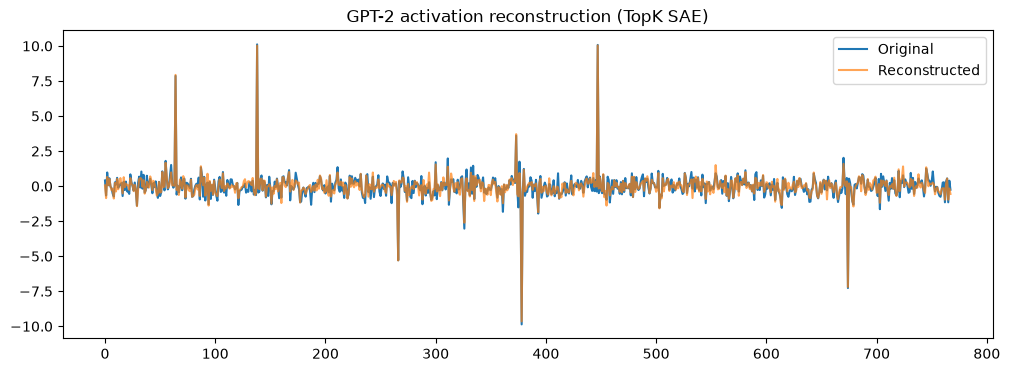

In [16]:
import matplotlib.pyplot as plt

idx = 0
original = sample[idx].cpu()
reconstructed = reconstructed[idx].cpu()

plt.figure(figsize=(12, 4))

plt.plot(original.numpy(), label="Original")
plt.plot(reconstructed.numpy(), label="Reconstructed", alpha=0.7)

plt.legend()
plt.title("GPT-2 activation reconstruction (TopK SAE)")
plt.show()